In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json
import logging
from pathlib import Path
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Setup
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
np.random.seed(42)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Setup complete")
print(f"API Key loaded: {bool(os.getenv('ANTHROPIC_API_KEY'))}")

✅ Setup complete
API Key loaded: True


In [7]:
# Load feedback data
df = pd.read_csv("../data/feedback.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few comments:")
for i, comment in enumerate(df['comment'].head(3)):
    print(f"\n{i+1}. {comment[:150]}...")

print(f"\n\nTotal comments: {len(df)}")

Dataset shape: (5000, 1)
Columns: ['comment']

First few comments:

1. easy, very accessible...

2. Just a horrible app with a sign up experience from hell. You need to create some special oddball device ID thing. I immediately trashed the app and wi...

3. Downloaded the latest update and it still logs me off as soon as I enter my current account . Who tests these??? IP 6S...


Total comments: 5000


In [8]:
from pathlib import Path
import os

# Ensure we're working from the project root
# (notebooks are in notebooks/ subdirectory)
os.chdir('..')  # Go up one level to project root

# Create outputs directory
Path("outputs").mkdir(exist_ok=True)

print("Working directory:", os.getcwd())
print("Outputs directory ready")

Working directory: /Users/conkey/Designing-an-End-to-End-LLM-Pipeline-for-Customer-Insight-Extraction-/llm-challenge
Outputs directory ready


In [9]:
# Calculate basic metrics
df['length'] = df['comment'].str.len()
df['word_count'] = df['comment'].str.split().str.len()

print("BASIC STATISTICS")

# Duplicates
unique_count = df['comment'].nunique()
duplicate_count = len(df) - unique_count
print(f"\n Dataset Overview:")
print(f"  Total comments: {len(df):,}")
print(f"  Unique comments: {unique_count:,}")
print(f"  Duplicates: {duplicate_count:,} ({duplicate_count/len(df)*100:.2f}%)")

# Length analysis
print(f"\n Comment Length (characters):")
print(f"  Min:    {df['length'].min()}")
print(f"  Max:    {df['length'].max()}")
print(f"  Mean:   {df['length'].mean():.1f}")
print(f"  Median: {df['length'].median():.1f}")
print(f"  Std:    {df['length'].std():.1f}")
print(f"  P25:    {df['length'].quantile(0.25):.0f}")
print(f"  P75:    {df['length'].quantile(0.75):.0f}")

# Word count analysis
print(f"\n Word Count:")
print(f"  Min:    {df['word_count'].min()}")
print(f"  Max:    {df['word_count'].max()}")
print(f"  Mean:   {df['word_count'].mean():.1f}")
print(f"  Median: {df['word_count'].median():.1f}")
print(f"  Std:    {df['word_count'].std():.1f}")

# Distribution breakdown
print(f"\n Length Distribution:")
length_bins = pd.cut(df['length'], bins=[0, 5, 200, 500, float('inf')],
                     labels=['Very Short (<50)', 'Short (50-200)', 'Medium (200-500)', 'Long (>500)'])
print(length_bins.value_counts().sort_index())

BASIC STATISTICS

 Dataset Overview:
  Total comments: 5,000
  Unique comments: 5,000
  Duplicates: 0 (0.00%)

 Comment Length (characters):
  Min:    2
  Max:    4117
  Mean:   160.0
  Median: 89.0
  Std:    222.5
  P25:    41
  P75:    189

 Word Count:
  Min:    1
  Max:    828
  Mean:   29.4
  Median: 16.0
  Std:    41.2

 Length Distribution:
length
Very Short (<50)      12
Short (50-200)      3831
Medium (200-500)     914
Long (>500)          243
Name: count, dtype: int64


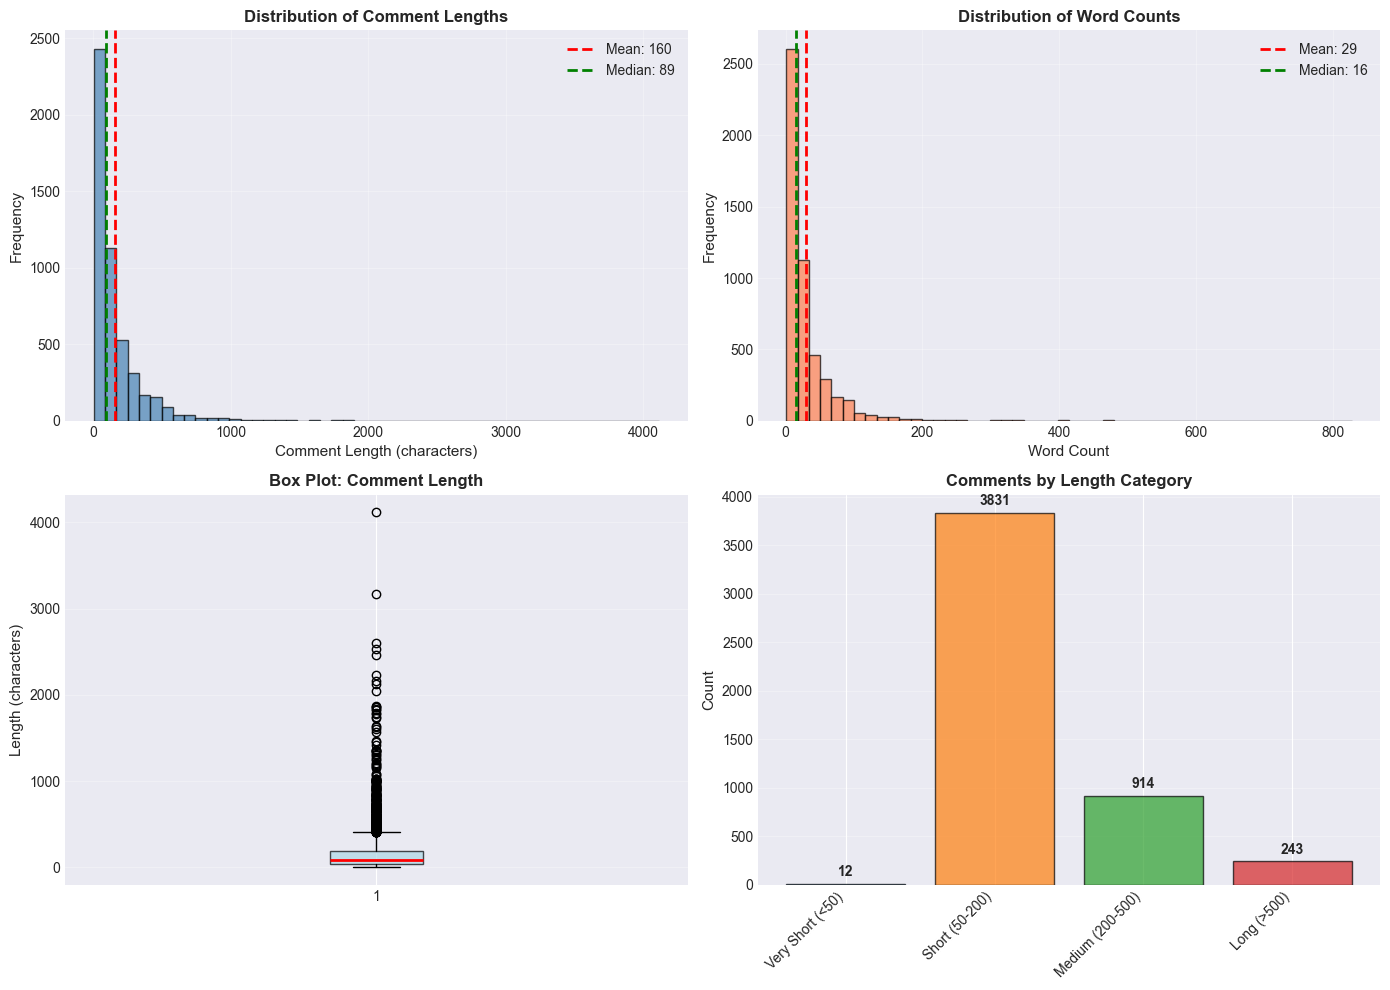

Saved: outputs/01_length_distribution.png


In [10]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Length histogram
axes[0, 0].hist(df['length'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df['length'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['length'].mean():.0f}")
axes[0, 0].axvline(df['length'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df['length'].median():.0f}")
axes[0, 0].set_xlabel('Comment Length (characters)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Comment Lengths', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Word count histogram
axes[0, 1].hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['word_count'].mean():.0f}")
axes[0, 1].axvline(df['word_count'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df['word_count'].median():.0f}")
axes[0, 1].set_xlabel('Word Count', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Word Counts', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Box plot for length
axes[1, 0].boxplot([df['length']], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('Length (characters)', fontsize=11)
axes[1, 0].set_title('Box Plot: Comment Length', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')

# Length category distribution
length_category_counts = length_bins.value_counts().sort_index()
axes[1, 1].bar(range(len(length_category_counts)), length_category_counts.values,
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(len(length_category_counts)))
axes[1, 1].set_xticklabels(length_category_counts.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].set_title('Comments by Length Category', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# Add counts on bars
for i, v in enumerate(length_category_counts.values):
    axes[1, 1].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/01_length_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved: outputs/01_length_distribution.png")

SENTIMENT DISTRIBUTION (Heuristic-based)

Note: This is a rough heuristic for exploration only

NEGATIVE  :   926 ( 18.5%) █████████
NEUTRAL   :  1438 ( 28.8%) ██████████████
POSITIVE  :  2636 ( 52.7%) ██████████████████████████


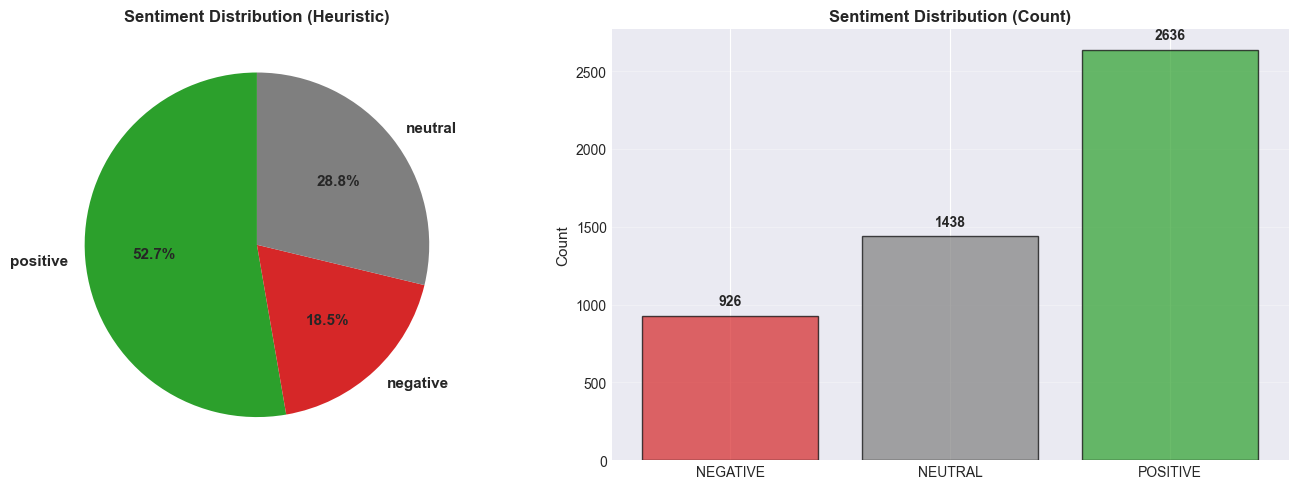


 Saved: outputs/02_sentiment_distribution.png


In [11]:
# Simple heuristic sentiment detection (for exploration only)
positive_words = {
    'love', 'great', 'excellent', 'good', 'happy', 'amazing', 'brilliant',
    'fantastic', 'perfect', 'best', 'wonderful', 'awesome', 'easy', 'smooth',
    'simple', 'quick', 'fast', 'reliable', 'stable', 'satisfied', 'pleased',
    'impressed', 'delighted', 'good', 'works', 'enjoy', 'great'
}

negative_words = {
    'hate', 'bad', 'terrible', 'awful', 'horrible', 'worst', 'poor', 'problem',
    'issue', 'broken', 'fail', 'error', 'crash', 'slow', 'confusing', 'difficult',
    'annoying', 'frustrating', 'useless', 'waste', 'don\'t', 'doesn\'t', 'can\'t',
    'cannot', 'impossible', 'rubbish', 'trash', 'pathetic', 'disaster'
}

sentiments = []
for comment in df['comment'].str.lower():
    pos_count = sum(1 for word in positive_words if word in comment)
    neg_count = sum(1 for word in negative_words if word in comment)

    if pos_count > neg_count:
        sentiments.append('positive')
    elif neg_count > pos_count:
        sentiments.append('negative')
    else:
        sentiments.append('neutral')

df['rough_sentiment'] = sentiments
sentiment_dist = Counter(sentiments)

print("SENTIMENT DISTRIBUTION (Heuristic-based)")
print("\nNote: This is a rough heuristic for exploration only\n")

for sentiment, count in sorted(sentiment_dist.items()):
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"{sentiment.upper():10s}: {count:5d} ({pct:5.1f}%) {bar}")

# Visualize sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = {'positive': '#2ca02c', 'negative': '#d62728', 'neutral': '#7f7f7f'}
sentiment_colors = [colors[s] for s in sentiment_dist.keys()]
axes[0].pie(sentiment_dist.values(), labels=sentiment_dist.keys(), autopct='%1.1f%%',
            colors=sentiment_colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Sentiment Distribution (Heuristic)', fontsize=12, fontweight='bold')

# Bar chart
sentiments_sorted = sorted(sentiment_dist.items())
axes[1].bar(range(len(sentiments_sorted)), [v for k, v in sentiments_sorted],
            color=[colors[k] for k, v in sentiments_sorted], alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(sentiments_sorted)))
axes[1].set_xticklabels([k.upper() for k, v in sentiments_sorted])
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Sentiment Distribution (Count)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

# Add counts on bars
for i, (k, v) in enumerate(sentiments_sorted):
    axes[1].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/02_sentiment_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n Saved: outputs/02_sentiment_distribution.png")

TOP TERMS BY TF-IDF (Exploratory)

 1. app                  0.1134  ███████████
 2. bank                 0.0729  ███████
 3. use                  0.0693  ██████
 4. easy                 0.0685  ██████
 5. good                 0.0663  ██████
 6. great                0.0610  ██████
 7. account              0.0567  █████
 8. banking              0.0533  █████
 9. service              0.0526  █████
10. update               0.0427  ████
11. best                 0.0426  ████
12. money                0.0372  ███
13. card                 0.0363  ███
14. just                 0.0357  ███
15. really               0.0353  ███
16. love                 0.0344  ███
17. time                 0.0315  ███
18. excellent            0.0290  ██
19. need                 0.0290  ██
20. like                 0.0288  ██


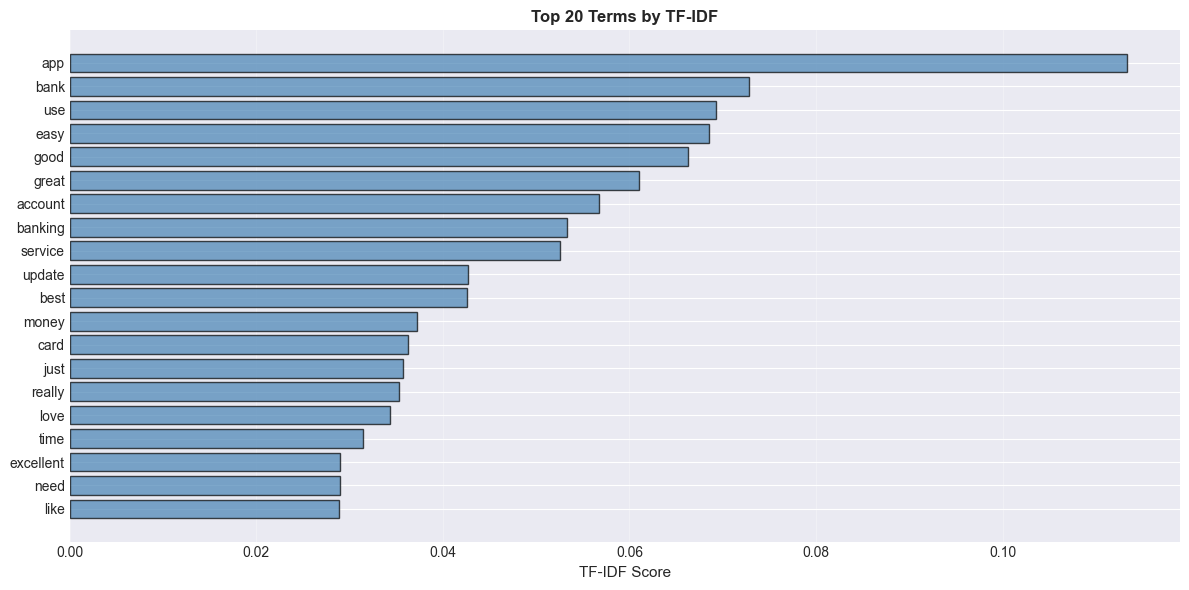


 Saved: outputs/03_top_terms_tfidf.png


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Compute TF-IDF
vectorizer = TfidfVectorizer(max_features=50, stop_words='english', lowercase=True)
tfidf_matrix = vectorizer.fit_transform(df['comment'])

# Get feature names and mean scores
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.mean(axis=0).A1

# Sort by score
top_n = 20
top_indices = np.argsort(tfidf_scores)[-top_n:][::-1]
top_terms = [(feature_names[i], tfidf_scores[i]) for i in top_indices]

print("TOP TERMS BY TF-IDF (Exploratory)\n")

for i, (term, score) in enumerate(top_terms, 1):
    bar = '█' * int(score * 100)
    print(f"{i:2d}. {term:20s} {score:.4f}  {bar}")

# Visualize top terms
fig, ax = plt.subplots(figsize=(12, 6))

terms, scores = zip(*top_terms)
ax.barh(range(len(terms)), scores, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(terms)))
ax.set_yticklabels(terms, fontsize=10)
ax.set_xlabel('TF-IDF Score', fontsize=11)
ax.set_title('Top 20 Terms by TF-IDF', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Reverse y-axis so highest is on top
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/03_top_terms_tfidf.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n Saved: outputs/03_top_terms_tfidf.png")

In [13]:
# Create length bins
df['length_bin'] = pd.cut(df['length'],
                          bins=[0, 50, 200, float('inf')],
                          labels=['short', 'medium', 'long'])

print("CREATING STRATIFIED SAMPLE")

print("Original dataset distribution:")
print(f"  By length: \n{df['length_bin'].value_counts().sort_index()}")
print(f"\n  By sentiment: \n{df['rough_sentiment'].value_counts()}")

# Create stratified sample
# We want to sample across length_bin and rough_sentiment
target_sample_size = 20

strata = df.groupby(['length_bin', 'rough_sentiment'], group_keys=False).apply(
    lambda x: x.sample(min(len(x), max(1, target_sample_size // 6)), random_state=42)
)

sample = strata.head(target_sample_size).reset_index(drop=True)

print(f"\n\nStratified sample (n={len(sample)}) distribution:")
print(f"  By length: \n{sample['length_bin'].value_counts().sort_index()}")
print(f"\n  By sentiment: \n{sample['rough_sentiment'].value_counts()}")

# Save sample
sample.to_csv('outputs/phase0_sample_20comments.csv', index=False)
print(f"\n Saved: outputs/phase0_sample_20comments.csv")

# Display sample comments
print("SAMPLE COMMENTS")

for idx, row in sample.iterrows():
    print(f"\n--- SAMPLE {idx+1} ---")
    print(f"Length: {row['length']} chars | Sentiment: {row['rough_sentiment']} | Category: {row['length_bin']}")
    print(f"Comment: {row['comment'][:120]}...")

CREATING STRATIFIED SAMPLE
Original dataset distribution:
  By length: 
length_bin
short     1575
medium    2268
long      1157
Name: count, dtype: int64

  By sentiment: 
rough_sentiment
positive    2636
neutral     1438
negative     926
Name: count, dtype: int64


Stratified sample (n=20) distribution:
  By length: 
length_bin
short     9
medium    9
long      2
Name: count, dtype: int64

  By sentiment: 
rough_sentiment
negative    8
neutral     6
positive    6
Name: count, dtype: int64

 Saved: outputs/phase0_sample_20comments.csv
SAMPLE COMMENTS

--- SAMPLE 1 ---
Length: 35 chars | Sentiment: negative | Category: short
Comment: Terrible experience .... Not useful...

--- SAMPLE 2 ---
Length: 50 chars | Sentiment: negative | Category: short
Comment: Using it for a while now and didn't had any issues...

--- SAMPLE 3 ---
Length: 30 chars | Sentiment: negative | Category: short
Comment: Awful but that's how I like it...

--- SAMPLE 4 ---
Length: 11 chars | Sentiment: neutral | Catego

/var/folders/yk/83x2smm96b9_trlwmwsyv1g00000gn/T/ipykernel_63157/1568750695.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  strata = df.groupby(['length_bin', 'rough_sentiment'], group_keys=False).apply(
/var/folders/yk/83x2smm96b9_trlwmwsyv1g00000gn/T/ipykernel_63157/1568750695.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strata = df.groupby(['length_bin', 'rough_sentiment'], group_keys=False).apply(
